# Notebook 05 — Traditional Text Representation and Hybrid Modelling

## Objective

This notebook evaluates the predictive contribution of borrower-written loan
descriptions using a traditional TF-IDF representation.

The experiments use the matched text-eligible temporal cohort established in
Notebook 03 and compare three controlled representations:

1. text-only TF-IDF;
2. structured-only predictors on the same borrowers; and
3. structured + TF-IDF hybrid predictors.

The common cohort and temporal split allow the incremental contribution of
borrower text to be measured without confounding differences in sample
composition.

The notebook also establishes the traditional text baseline against which the
contextual BERT-derived representation will subsequently be compared.


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Credit_Risk_Thesis"
)

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"

NB2_OUTPUT_DIR = PROCESSED_DATA_DIR / "notebook_02"
NB3_OUTPUT_DIR = PROCESSED_DATA_DIR / "notebook_03"
NB5_OUTPUT_DIR = PROCESSED_DATA_DIR / "notebook_05"

OUTPUT_DIR = PROJECT_ROOT / "outputs"
MODEL_DIR = OUTPUT_DIR / "models"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"

NB5_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT)
print("Notebook 03 input:", NB3_OUTPUT_DIR)
print("Notebook 05 output:", NB5_OUTPUT_DIR)

Project root: /content/drive/MyDrive/Credit_Risk_Thesis
Notebook 03 input: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_03
Notebook 05 output: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_05


## 1. Load Text-Cohort Handoff

Notebook 03 identified the subset of resolved Lending Club loans for which
borrower-written descriptions are available and established a dedicated
temporal split for the text experiments.

The persisted row indices are loaded here to reconstruct exactly the same
text-eligible train, validation, and test cohorts without redefining cohort
membership in the modelling notebook.


In [5]:
TEXT_TRAIN_IDX_FILE = (
    NB3_OUTPUT_DIR / "text_train_indices.npy"
)

TEXT_VAL_IDX_FILE = (
    NB3_OUTPUT_DIR / "text_val_indices.npy"
)

TEXT_TEST_IDX_FILE = (
    NB3_OUTPUT_DIR / "text_test_indices.npy"
)

TEXT_SPLIT_FILE = (
    NB3_OUTPUT_DIR / "text_cohort_split_definition.csv"
)

required_files = [
    TEXT_TRAIN_IDX_FILE,
    TEXT_VAL_IDX_FILE,
    TEXT_TEST_IDX_FILE,
    TEXT_SPLIT_FILE
]

for file_path in required_files:
    print(
        file_path.name,
        "->",
        "FOUND" if file_path.exists() else "MISSING"
    )

text_train_indices.npy -> FOUND
text_val_indices.npy -> FOUND
text_test_indices.npy -> FOUND
text_cohort_split_definition.csv -> FOUND


In [6]:
text_train_indices = np.load(
    TEXT_TRAIN_IDX_FILE
)

text_val_indices = np.load(
    TEXT_VAL_IDX_FILE
)

text_test_indices = np.load(
    TEXT_TEST_IDX_FILE
)

text_split_definition = pd.read_csv(
    TEXT_SPLIT_FILE
)

print(
    "Text train indices:",
    len(text_train_indices)
)

print(
    "Text validation indices:",
    len(text_val_indices)
)

print(
    "Text test indices:",
    len(text_test_indices)
)

display(text_split_definition)

Text train indices: 59350
Text validation indices: 48726
Text test indices: 15175


,split,start_year,end_year,text_required,rows
0,train,2007,2012,True,59350
1,validation,2013,2013,True,48726
2,test,2014,2014,True,15175


## 2. Reconstruct the Text-Eligible Modelling Cohort

Notebook 03 persisted the original row indices defining the text-eligible
training, validation, and test cohorts.

This section reconstructs only the variables required for text modelling:
the borrower description (`desc`), the binary target (`default_flag`), and
the issue year used for temporal validation.

No structured feature engineering is repeated here.


In [7]:
# Inspect the available processed-data artifacts before loading the source data.

print("Processed data directory:")
print(PROCESSED_DATA_DIR)

print("\nAvailable files/directories:")
for path in sorted(PROCESSED_DATA_DIR.iterdir()):
    print(" -", path.name)

Processed data directory:
/content/drive/MyDrive/Credit_Risk_Thesis/data/processed

Available files/directories:
 - notebook_02
 - notebook_03
 - notebook_04
 - notebook_05
 - notebook_06


### 2.1 Load Minimal Source Data for Text Modelling

Notebook 03 persisted the original row indices defining the matched
text-eligible cohort but did not duplicate the underlying borrower-description
text.

Therefore, only the raw variables required for text modelling are reloaded:
the borrower description (`desc`), loan outcome (`loan_status`), and loan issue
date (`issue_d`).

The original row index is preserved so that the saved Notebook 03 cohort
indices can be applied exactly.


In [8]:
RAW_DATA_DIR = DATA_DIR / "raw"

RAW_DATA_FILE = (
    RAW_DATA_DIR / "accepted_2007_to_2018Q4.csv"
)

assert RAW_DATA_FILE.exists()

print("Raw data file found.")

Raw data file found.


In [9]:
text_source_df = pd.read_csv(
    RAW_DATA_FILE,
    usecols=[
        "desc",
        "loan_status",
        "issue_d"
    ],
    low_memory=False
)

print(
    "Text source shape:",
    text_source_df.shape
)

Text source shape: (2260701, 3)


In [10]:
text_model_df = (
    text_source_df[
        text_source_df["loan_status"].isin(
            ["Fully Paid", "Charged Off"]
        )
    ]
    .copy()
)

text_model_df["default_flag"] = (
    text_model_df["loan_status"]
    .map({
        "Fully Paid": 0,
        "Charged Off": 1
    })
    .astype("int8")
)

text_model_df["issue_date"] = pd.to_datetime(
    text_model_df["issue_d"],
    format="%b-%Y",
    errors="coerce"
)

text_model_df["issue_year"] = (
    text_model_df["issue_date"].dt.year
)

print(
    "Resolved text-source rows:",
    len(text_model_df)
)

Resolved text-source rows: 1345310


In [11]:
text_train_df = text_model_df.loc[
    text_train_indices,
    ["desc", "default_flag", "issue_year"]
].copy()

text_val_df = text_model_df.loc[
    text_val_indices,
    ["desc", "default_flag", "issue_year"]
].copy()

text_test_df = text_model_df.loc[
    text_test_indices,
    ["desc", "default_flag", "issue_year"]
].copy()

print("Text train:", text_train_df.shape)
print("Text validation:", text_val_df.shape)
print("Text test:", text_test_df.shape)

Text train: (59350, 3)
Text validation: (48726, 3)
Text test: (15175, 3)


In [12]:
assert len(text_train_df) == 59350
assert len(text_val_df) == 48726
assert len(text_test_df) == 15175

assert text_train_df["issue_year"].between(
    2007, 2012
).all()

assert (
    text_val_df["issue_year"] == 2013
).all()

assert (
    text_test_df["issue_year"] == 2014
).all()

assert text_train_df["desc"].notna().all()
assert text_val_df["desc"].notna().all()
assert text_test_df["desc"].notna().all()

print("Matched text cohort reconstructed and validated.")

Matched text cohort reconstructed and validated.


## 3. Text Characteristics

Before constructing text representations, the borrower descriptions are
examined for basic document-length and formatting characteristics.

The objective is to understand the distribution of text length, identify
potentially empty or extremely short descriptions, and determine whether
aggressive text cleaning is necessary.

No vocabulary is learned from validation or test data in this section.


In [13]:
for df_name, current_df in [
    ("Train", text_train_df),
    ("Validation", text_val_df),
    ("Test", text_test_df)
]:
    current_df["char_count"] = (
        current_df["desc"]
        .astype(str)
        .str.len()
    )

    current_df["word_count"] = (
        current_df["desc"]
        .astype(str)
        .str.split()
        .str.len()
    )

    print(f"\n{df_name}")
    print(
        current_df[
            ["char_count", "word_count"]
        ].describe(
            percentiles=[
                0.25,
                0.50,
                0.75,
                0.90,
                0.95,
                0.99
            ]
        ).round(2)
    )


Train
       char_count  word_count
count    59350.00    59350.00
mean       317.58       56.86
std        345.40       61.67
min          1.00        1.00
25%        118.00       20.00
50%        223.50       40.00
75%        352.00       65.75
90%        657.00      119.00
95%        927.55      167.00
99%       1804.02      321.00
max       3988.00      815.00

Validation
       char_count  word_count
count    48726.00    48726.00
mean       167.04       29.59
std        113.83       21.62
min          2.00        1.00
25%         84.00       14.00
50%        134.00       23.00
75%        226.00       41.00
90%        319.00       58.00
95%        334.00       64.00
99%        586.00      106.00
max       2365.00      413.00

Test
       char_count  word_count
count    15175.00    15175.00
mean       150.71       26.37
std        103.56       19.61
min         39.00        6.00
25%         76.00       12.00
50%        117.00       20.00
75%        200.00       36.00
90%        297.

In [14]:
# Check very short descriptions
text_length_summary = pd.DataFrame([
    {
        "split": "Train",
        "rows": len(text_train_df),
        "under_5_words": (
            text_train_df["word_count"] < 5
        ).sum(),
        "under_10_words": (
            text_train_df["word_count"] < 10
        ).sum()
    },
    {
        "split": "Validation",
        "rows": len(text_val_df),
        "under_5_words": (
            text_val_df["word_count"] < 5
        ).sum(),
        "under_10_words": (
            text_val_df["word_count"] < 10
        ).sum()
    },
    {
        "split": "Test",
        "rows": len(text_test_df),
        "under_5_words": (
            text_test_df["word_count"] < 5
        ).sum(),
        "under_10_words": (
            text_test_df["word_count"] < 10
        ).sum()
    }
])

text_length_summary["under_5_words_pct"] = (
    text_length_summary["under_5_words"]
    / text_length_summary["rows"]
    * 100
).round(2)

text_length_summary["under_10_words_pct"] = (
    text_length_summary["under_10_words"]
    / text_length_summary["rows"]
    * 100
).round(2)

text_length_summary

,split,rows,under_5_words,under_10_words,under_5_words_pct,under_10_words_pct
0,Train,59350,249,3997,0.42,6.73
1,Validation,48726,9,5780,0.02,11.86
2,Test,15175,0,2158,0.00,14.22


In [15]:
pd.set_option(
    "display.max_colwidth",
    300
)

text_train_df[
    ["desc", "default_flag", "word_count"]
].sample(
    10,
    random_state=42
)

,desc,default_flag,word_count
1649688,"I currently have $15,000 spread out over 7 credit cards- with interest rates ranging from 9.99% to 18.99%. I would like to consolidate this debt into one loan so that I can reduce my interest rate and pay it off in a timely manner. I own my car outright- I have moved back in with my parents a...",0,173
1645799,576436 added on 11/17/09 > I pay my bills on time and i have a very very stable job<br/> 576436 added on 11/17/09 > I plan to use these funds to consolidate my debt into one easy payment. I also live with my parents so i dont have a house/rent payment.<br/>,0,51
1912046,Borrower added on 08/10/12 > Debt Reconsolidation<br>,0,7
1895266,Borrower added on 11/06/12 > Pay off an interest only loan at a higher interest rate<br>,0,16
1913741,Borrower added on 07/30/12 > just want to pay off all my credit cards and free up some money and to be able to just pay one bill.<br><br> Borrower added on 07/30/12 > Tell your story. What is your loan for?<br>,0,41
1929912,Borrower added on 04/03/12 > Help me consolidate two credit cards into one low rate.<br>Thanks<br>,0,15
1632767,"Borrower added on 01/11/11 > Trying to get some extra money for our 2011 wedding expenses. Also would like to pay off some high interest credit cards. I have a stable job as an RN and am a reliable, on time bill payer.<br/> Borrower added on 01/13/11 > Thank you for all who have funded so fa...",0,70
1911097,Borrower added on 08/15/12 > The purpose of the loan is to consolidate some medical expenses related to my son's birth and additional medical attention.<br>,0,25
1644983,Borrower added on 01/05/10 > I am trying to consolidate a student loan I've had for some time and my credit card. It would be a lot easier to make one payment for two bills. I've tried to get a line of credit from Citizens and PNC but do not meet their requirements in this economy. I've got...,0,120
1896645,Borrower added on 10/30/12 > The loan will pay off three credit cards.<br>,0,13


### 3.1 Text Preprocessing Strategy

Borrower descriptions exhibit a substantial temporal change in document length.
The median description decreases from 40 words in the 2007–2012 training cohort
to 23 words in 2013 and 20 words in 2014. The proportion of descriptions
containing fewer than 10 words correspondingly increases from 6.73% to 11.86%
and 14.22%.

Short descriptions are retained because they represent genuine observations
within the predefined matched cohort and may still contain useful predictive
information.

For the initial sparse text representation, preprocessing is intentionally
conservative. Text is converted to string form and whitespace is normalized.
Lowercasing and tokenization are subsequently handled by the TF-IDF vectorizer.
No stemming or lemmatization is applied.


In [16]:
import re

def normalize_text(text):
    """
    Apply minimal normalization while preserving
    the lexical content of borrower descriptions.
    """
    text = str(text)

    # Collapse repeated whitespace/newlines.
    text = re.sub(r"\s+", " ", text)

    return text.strip()


text_train_df["clean_desc"] = (
    text_train_df["desc"].map(normalize_text)
)

text_val_df["clean_desc"] = (
    text_val_df["desc"].map(normalize_text)
)

text_test_df["clean_desc"] = (
    text_test_df["desc"].map(normalize_text)
)

print("Text normalization complete.")

Text normalization complete.


In [17]:
cleaning_validation = pd.DataFrame({
    "split": [
        "Train",
        "Validation",
        "Test"
    ],
    "rows": [
        len(text_train_df),
        len(text_val_df),
        len(text_test_df)
    ],
    "empty_after_cleaning": [
        text_train_df["clean_desc"].eq("").sum(),
        text_val_df["clean_desc"].eq("").sum(),
        text_test_df["clean_desc"].eq("").sum()
    ]
})

cleaning_validation

,split,rows,empty_after_cleaning
0,Train,59350,0
1,Validation,48726,0
2,Test,15175,0


In [18]:
X_text_train = text_train_df["clean_desc"]
X_text_val = text_val_df["clean_desc"]
X_text_test = text_test_df["clean_desc"]

y_text_train = (
    text_train_df["default_flag"]
    .to_numpy()
)

y_text_val = (
    text_val_df["default_flag"]
    .to_numpy()
)

y_text_test = (
    text_test_df["default_flag"]
    .to_numpy()
)

print("Text train:", len(X_text_train), len(y_text_train))
print("Text validation:", len(X_text_val), len(y_text_val))
print("Text test:", len(X_text_test), len(y_text_test))

Text train: 59350 59350
Text validation: 48726 48726
Text test: 15175 15175


In [19]:
text_target_summary = pd.DataFrame({
    "split": [
        "Train",
        "Validation",
        "Test"
    ],
    "rows": [
        len(y_text_train),
        len(y_text_val),
        len(y_text_test)
    ],
    "defaults": [
        y_text_train.sum(),
        y_text_val.sum(),
        y_text_test.sum()
    ]
})

text_target_summary["default_rate_pct"] = (
    text_target_summary["defaults"]
    / text_target_summary["rows"]
    * 100
).round(2)

text_target_summary

,split,rows,defaults,default_rate_pct
0,Train,59350,9107,15.34
1,Validation,48726,7388,15.16
2,Test,15175,2405,15.85


## 4. TF-IDF Text Representation

The first text representation uses Term Frequency–Inverse Document Frequency
(TF-IDF), providing an interpretable sparse baseline for borrower-description
modelling.

The vocabulary and inverse-document-frequency statistics are learned exclusively
from the 2007–2012 training cohort. The fitted vectorizer is then applied without
refitting to the 2013 validation and 2014 test cohorts, preventing temporal
information leakage.

Both unigrams and bigrams are considered so that the representation can capture
individual terms as well as short lexical phrases.


In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    max_features=50000,
    sublinear_tf=True,
    dtype=np.float32
)

X_tfidf_train = tfidf_vectorizer.fit_transform(
    X_text_train
)

X_tfidf_val = tfidf_vectorizer.transform(
    X_text_val
)

X_tfidf_test = tfidf_vectorizer.transform(
    X_text_test
)

print("TF-IDF train shape:", X_tfidf_train.shape)
print("TF-IDF validation shape:", X_tfidf_val.shape)
print("TF-IDF test shape:", X_tfidf_test.shape)

print(
    "\nVocabulary size:",
    len(tfidf_vectorizer.vocabulary_)
)

TF-IDF train shape: (59350, 42436)
TF-IDF validation shape: (48726, 42436)
TF-IDF test shape: (15175, 42436)

Vocabulary size: 42436


In [21]:
assert X_tfidf_train.shape[0] == 59350
assert X_tfidf_val.shape[0] == 48726
assert X_tfidf_test.shape[0] == 15175

assert X_tfidf_train.shape[1] == X_tfidf_val.shape[1]
assert X_tfidf_train.shape[1] == X_tfidf_test.shape[1]

assert X_tfidf_train.shape[1] <= 50000

print("TF-IDF matrices validated.")

TF-IDF matrices validated.


In [22]:
tfidf_feature_names = (
    tfidf_vectorizer.get_feature_names_out()
)

unigram_count = sum(
    " " not in feature
    for feature in tfidf_feature_names
)

bigram_count = sum(
    " " in feature
    for feature in tfidf_feature_names
)

print("Total TF-IDF features:", len(tfidf_feature_names))
print("Unigrams:", unigram_count)
print("Bigrams:", bigram_count)

print("\nSample features:")
print(tfidf_feature_names[:30])

Total TF-IDF features: 42436
Unigrams: 8500
Bigrams: 33936

Sample features:
['00' '00 00' '00 000' '00 12' '00 13' '00 15' '00 150' '00 16' '00 18'
 '00 19' '00 21' '00 22' '00 24' '00 25' '00 29' '00 300' '00 50'
 '00 annually' '00 apr' '00 auto' '00 average' '00 away' '00 balance'
 '00 bank' '00 br' '00 buy' '00 cable' '00 capital' '00 car' '00 cards']


## 5. TF-IDF Logistic Regression Baseline

A logistic regression classifier is trained on the TF-IDF representation to
establish an interpretable text-only baseline.

The model is fitted exclusively on the 2007–2012 training cohort. Model
selection is based on the 2013 validation cohort, while the 2014 cohort remains
untouched until final evaluation.

Because the objective is probability-based credit-risk prediction rather than
only hard classification, evaluation emphasizes ROC-AUC, PR-AUC, Brier score,
and calibration in addition to threshold-dependent classification metrics.


In [23]:
from sklearn.linear_model import LogisticRegression

tfidf_lr = LogisticRegression(
    C=1.0,
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

tfidf_lr.fit(
    X_tfidf_train,
    y_text_train
)

print("TF-IDF Logistic Regression fitted.")
print("Iterations:", tfidf_lr.n_iter_)

TF-IDF Logistic Regression fitted.
Iterations: [11]


In [24]:
tfidf_lr_val_prob = tfidf_lr.predict_proba(
    X_tfidf_val
)[:, 1]

print(
    "Validation probability range:",
    round(tfidf_lr_val_prob.min(), 4),
    "to",
    round(tfidf_lr_val_prob.max(), 4)
)

print(
    "Mean predicted default probability:",
    round(tfidf_lr_val_prob.mean(), 4)
)

print(
    "Observed validation default rate:",
    round(y_text_val.mean(), 4)
)

Validation probability range: 0.0177 to 0.6356
Mean predicted default probability: 0.1615
Observed validation default rate: 0.1516


In [25]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

tfidf_lr_val_pred = (
    tfidf_lr_val_prob >= 0.5
).astype(int)

tfidf_lr_val_metrics = pd.DataFrame([{
    "model": "TF-IDF Logistic Regression",
    "split": "Validation",
    "accuracy": accuracy_score(
        y_text_val,
        tfidf_lr_val_pred
    ),
    "precision": precision_score(
        y_text_val,
        tfidf_lr_val_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_text_val,
        tfidf_lr_val_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_text_val,
        tfidf_lr_val_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_text_val,
        tfidf_lr_val_prob
    ),
    "pr_auc": average_precision_score(
        y_text_val,
        tfidf_lr_val_prob
    ),
    "brier_score": brier_score_loss(
        y_text_val,
        tfidf_lr_val_prob
    ),
    "predicted_default_pct":
        tfidf_lr_val_pred.mean() * 100
}])

numeric_cols = tfidf_lr_val_metrics.select_dtypes(
    include=np.number
).columns

tfidf_lr_val_metrics[numeric_cols] = (
    tfidf_lr_val_metrics[numeric_cols].round(4)
)

tfidf_lr_val_metrics

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct
0,TF-IDF Logistic Regression,Validation,0.848,0.2927,0.0016,0.0032,0.5755,0.1874,0.129,0.0841


### 5.1 Regularization Selection

The inverse regularization parameter `C` is evaluated using the 2013
validation cohort. Smaller values impose stronger L2 regularization.

Model selection is based primarily on validation ROC-AUC and PR-AUC.
The 2014 test cohort is not used during hyperparameter selection.


In [26]:
C_values = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]

tfidf_lr_tuning_results = []

for C in C_values:

    model = LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_tfidf_train,
        y_text_train
    )

    val_prob = model.predict_proba(
        X_tfidf_val
    )[:, 1]

    tfidf_lr_tuning_results.append({
        "C": C,
        "roc_auc": roc_auc_score(
            y_text_val,
            val_prob
        ),
        "pr_auc": average_precision_score(
            y_text_val,
            val_prob
        ),
        "brier_score": brier_score_loss(
            y_text_val,
            val_prob
        )
    })

tfidf_lr_tuning_results = pd.DataFrame(
    tfidf_lr_tuning_results
)

tfidf_lr_tuning_results[
    ["roc_auc", "pr_auc", "brier_score"]
] = (
    tfidf_lr_tuning_results[
        ["roc_auc", "pr_auc", "brier_score"]
    ].round(4)
)

tfidf_lr_tuning_results

,C,roc_auc,pr_auc,brier_score
0,0.01,0.5835,0.1907,0.1281
1,0.05,0.5890,0.1942,0.1274
2,0.10,0.5897,0.1948,0.1272
3,0.50,0.5824,0.1911,0.1277
4,1.00,0.5755,0.1874,0.1290
5,2.00,0.5679,0.1833,0.1314
6,5.00,0.5587,0.1785,0.1371


### 5.2 Selected TF-IDF Logistic Regression

Regularization strength was selected using the 2013 validation cohort.
Among the evaluated values, `C = 0.10` achieved the highest validation
ROC-AUC and PR-AUC and the lowest Brier score.

The selected model is therefore refitted using the original 2007–2012
training cohort only. The 2014 test cohort remains untouched until final
out-of-time evaluation.


In [27]:
best_C = 0.10

tfidf_lr_final = LogisticRegression(
    C=best_C,
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

tfidf_lr_final.fit(
    X_tfidf_train,
    y_text_train
)

tfidf_val_prob_final = tfidf_lr_final.predict_proba(
    X_tfidf_val
)[:, 1]

tfidf_test_prob = tfidf_lr_final.predict_proba(
    X_tfidf_test
)[:, 1]

print("Selected C:", best_C)
print("Iterations:", tfidf_lr_final.n_iter_)
print(
    "Validation ROC-AUC:",
    round(roc_auc_score(y_text_val, tfidf_val_prob_final), 4)
)
print(
    "Test ROC-AUC:",
    round(roc_auc_score(y_text_test, tfidf_test_prob), 4)
)

Selected C: 0.1
Iterations: [7]
Validation ROC-AUC: 0.5897
Test ROC-AUC: 0.5715


### 5.3 Final Out-of-Time Evaluation

The selected TF-IDF logistic regression model is now evaluated on the
untouched 2014 test cohort.

ROC-AUC and PR-AUC measure discrimination and ranking performance, while
Brier score and expected calibration error (ECE) assess the quality of
the predicted probabilities. Threshold-dependent classification metrics
are also reported at the conventional 0.50 threshold for completeness,
but are not used as the primary basis for model comparison.


In [28]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

# Classification at conventional 0.50 threshold
tfidf_test_pred = (
    tfidf_test_prob >= 0.50
).astype(int)


def expected_calibration_error(
    y_true,
    y_prob,
    n_bins=10
):
    bins = np.linspace(0, 1, n_bins + 1)

    bin_ids = np.digitize(
        y_prob,
        bins[1:-1],
        right=True
    )

    ece = 0.0

    for bin_id in range(n_bins):

        mask = bin_ids == bin_id

        if mask.sum() == 0:
            continue

        observed = y_true[mask].mean()
        predicted = y_prob[mask].mean()

        ece += (
            mask.mean()
            * abs(observed - predicted)
        )

    return ece


tfidf_test_metrics = pd.DataFrame([{
    "model": "TF-IDF Logistic Regression",
    "split": "Test (2014)",
    "accuracy": accuracy_score(
        y_text_test,
        tfidf_test_pred
    ),
    "precision": precision_score(
        y_text_test,
        tfidf_test_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_text_test,
        tfidf_test_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_text_test,
        tfidf_test_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_text_test,
        tfidf_test_prob
    ),
    "pr_auc": average_precision_score(
        y_text_test,
        tfidf_test_prob
    ),
    "brier_score": brier_score_loss(
        y_text_test,
        tfidf_test_prob
    ),
    "ece_10_bins": expected_calibration_error(
        y_text_test,
        tfidf_test_prob,
        n_bins=10
    ),
    "predicted_default_pct": (
        tfidf_test_pred.mean() * 100
    ),
    "mean_predicted_probability": (
        tfidf_test_prob.mean()
    ),
    "observed_default_rate": (
        y_text_test.mean()
    )
}])

numeric_cols = tfidf_test_metrics.select_dtypes(
    include=np.number
).columns

tfidf_test_metrics[numeric_cols] = (
    tfidf_test_metrics[numeric_cols]
    .round(4)
)

tfidf_test_metrics

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,ece_10_bins,predicted_default_pct,mean_predicted_probability,observed_default_rate
0,TF-IDF Logistic Regression,Test (2014),0.8415,0.0,0.0,0.0,0.5715,0.1945,0.1323,0.0077,0.0,0.1508,0.1585


### 5.4 TF-IDF Feature Interpretation

The coefficients of the selected logistic regression model are inspected
to identify textual features associated with higher and lower predicted
default risk.

Positive coefficients indicate terms associated with increased predicted
default probability, while negative coefficients indicate terms associated
with decreased predicted default probability, conditional on the other
TF-IDF features.

These associations are predictive rather than causal and should therefore
not be interpreted as evidence that particular words themselves cause
default.


In [29]:
feature_names = np.array(
    tfidf_vectorizer.get_feature_names_out()
)

coefficients = tfidf_lr_final.coef_[0]

tfidf_coefficients = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

# Terms associated with higher predicted default risk
top_positive = (
    tfidf_coefficients
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

# Terms associated with lower predicted default risk
top_negative = (
    tfidf_coefficients
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(20)
    .reset_index(drop=True)
)

print("Top features associated with HIGHER predicted default risk:")
display(top_positive)

print("\nTop features associated with LOWER predicted default risk:")
display(top_negative)

Top features associated with HIGHER predicted default risk:


,feature,coefficient
0,business,1.412573
1,bills,1.388469
2,need,0.897153
3,br borrower,0.853954
4,help,0.692323
5,consolidate bills,0.593915
6,debt payment,0.551870
7,payment,0.527461
8,payment instead,0.496867
9,06,0.479986



Top features associated with LOWER predicted default risk:


,feature,coefficient
0,rate,-1.228687
1,pool,-0.749547
2,motorcycle,-0.650385
3,credit card,-0.611903
4,rates,-0.600690
5,college,-0.596300
6,card,-0.587091
7,apr,-0.565781
8,refinance,-0.552111
9,ve,-0.525168


### 5.5 Coefficient Sanity Check

Inspection of the largest TF-IDF coefficients identified both interpretable
financial language and several apparent formatting or tokenisation artifacts,
including numeric tokens and remnants such as `br`.

Rather than modifying the representation after observing validation and test
performance, the predefined TF-IDF pipeline is retained as the reproducible
baseline. The prevalence of potentially artifact-like features among the
largest coefficients is quantified below and considered when interpreting
the model.


In [30]:
import re

def artifact_flag(term):
    tokens = term.split()

    # Pure numeric token/bigram components
    has_numeric = any(
        re.fullmatch(r"\d+", token) is not None
        for token in tokens
    )

    # Common apparent formatting remnants observed in vocabulary
    has_format_remnant = any(
        token in {"br", "ve"}
        for token in tokens
    )

    return has_numeric or has_format_remnant


# Examine the 100 largest coefficients in each direction
top_100_positive = (
    tfidf_coefficients
    .nlargest(100, "coefficient")
    .copy()
)

top_100_negative = (
    tfidf_coefficients
    .nsmallest(100, "coefficient")
    .copy()
)

top_100_positive["artifact_flag"] = (
    top_100_positive["feature"].apply(artifact_flag)
)

top_100_negative["artifact_flag"] = (
    top_100_negative["feature"].apply(artifact_flag)
)

artifact_summary = pd.DataFrame({
    "direction": ["Higher risk", "Lower risk"],
    "top_features_examined": [100, 100],
    "artifact_like_features": [
        top_100_positive["artifact_flag"].sum(),
        top_100_negative["artifact_flag"].sum()
    ]
})

artifact_summary["artifact_pct"] = (
    artifact_summary["artifact_like_features"]
    / artifact_summary["top_features_examined"]
    * 100
).round(2)

artifact_summary

,direction,top_features_examined,artifact_like_features,artifact_pct
0,Higher risk,100,28,28.0
1,Lower risk,100,18,18.0


#### Interpretation

The coefficient inspection indicates that the TF-IDF model captures a
mixture of interpretable borrower language and dataset-specific textual
artifacts.

Using the predefined heuristic screening rule, 28% of the 100 coefficients
most strongly associated with higher predicted default risk were flagged as
potentially artifact-like, compared with 18% among the 100 strongest lower-risk
coefficients. These flags are diagnostic indicators rather than definitive
labels of textual artifacts. Examples include
numeric tokens and apparent formatting remnants such as `br`.

Consequently, individual TF-IDF coefficients should be interpreted
cautiously. Although economically meaningful terms such as `business`,
`bills`, `debt payment`, `credit card`, `refinance`, and `excellent credit`
also appear among the strongest coefficients, part of the predictive signal
may reflect historical formatting or vocabulary differences rather than
borrower semantics alone.

The TF-IDF specification is retained unchanged as the predefined sparse-text
baseline to avoid modifying the representation after observing validation
and test performance. The artifact analysis is therefore treated as an
interpretability limitation rather than as a basis for post-hoc model
redesign.


#### TF-IDF Representation Limitation

The predefined TF-IDF vectorizer uses English stop-word removal. This improves
sparsity but may also remove function words, including some forms of negation,
that could carry contextual meaning. Because the full validation and test
evaluation has already been completed, the representation is not redesigned
post hoc; this choice is retained as a limitation of the traditional sparse-text
baseline.


## 6. Matched-Cohort Structured Baseline

To measure the incremental predictive value of borrower text, a structured-only
baseline is evaluated on exactly the same borrowers used in the text experiment.

The structured feature-engineering specification established in Notebook 03 is
reused. However, preprocessing parameters such as numerical medians and
categorical encodings are estimated exclusively from the matched 2007–2012
training cohort and then applied unchanged to the 2013 validation and 2014 test
cohorts.

This preserves the original preprocessing methodology while preventing temporal
information leakage.


### 6.1 Matched-Cohort Structured Reconstruction

The authoritative candidate-feature list produced by Notebook 02 is reused to
reconstruct the same structured source-feature definition applied in Notebook 03.
Only deterministic feature engineering is repeated here; all learned preprocessing
parameters are fitted exclusively on the matched 2007–2012 training cohort.


In [31]:
# Load the authoritative candidate-feature list produced by Notebook 02.
# Notebook 03 used this same artifact as its input feature specification.

NB2_OUTPUT_DIR = PROCESSED_DATA_DIR / "notebook_02"

CANDIDATE_FEATURE_FILE = (
    NB2_OUTPUT_DIR / "final_candidate_features.csv"
)

assert CANDIDATE_FEATURE_FILE.exists(), (
    f"Missing file: {CANDIDATE_FEATURE_FILE}"
)

candidate_features = (
    pd.read_csv(CANDIDATE_FEATURE_FILE)["feature"]
    .tolist()
)

TEXT_FEATURE = "desc"

structured_source_features = [
    feature
    for feature in candidate_features
    if feature != TEXT_FEATURE
]

assert len(candidate_features) == 64
assert len(structured_source_features) == 63

print("Candidate features:", len(candidate_features))
print("Structured source features:", len(structured_source_features))


Candidate features: 64
Structured source features: 63


In [32]:
def engineer_structured_features(df):
    """
    Apply the structured feature-engineering specification
    established in Notebook 03.

    This function performs deterministic transformations only.
    No medians, encoders, or other learned preprocessing
    parameters are estimated here.
    """

    df = df.copy()

    # -----------------------------------------
    # 1. FICO midpoint
    # -----------------------------------------
    df["fico_score"] = (
        df["fico_range_low"]
        + df["fico_range_high"]
    ) / 2

    df.drop(
        columns=[
            "fico_range_low",
            "fico_range_high"
        ],
        inplace=True
    )

    # -----------------------------------------
    # 2. Credit-history duration
    # -----------------------------------------
    issue_date = pd.to_datetime(
        df["issue_d"],
        format="%b-%Y",
        errors="coerce"
    )

    earliest_credit_date = pd.to_datetime(
        df["earliest_cr_line"],
        format="%b-%Y",
        errors="coerce"
    )

    df["credit_history_months"] = (
        (issue_date.dt.year - earliest_credit_date.dt.year) * 12
        + (issue_date.dt.month - earliest_credit_date.dt.month)
    )

    df.drop(
        columns=["earliest_cr_line"],
        inplace=True
    )

    # -----------------------------------------
    # 3. Employment-length conversion
    # -----------------------------------------
    emp_length_map = {
        "< 1 year": 0,
        "1 year": 1,
        "2 years": 2,
        "3 years": 3,
        "4 years": 4,
        "5 years": 5,
        "6 years": 6,
        "7 years": 7,
        "8 years": 8,
        "9 years": 9,
        "10+ years": 10
    }

    df["emp_length_years"] = (
        df["emp_length"]
        .map(emp_length_map)
    )

    df.drop(
        columns=["emp_length"],
        inplace=True
    )

    return df

In [33]:
matched_required_cols = list(
    dict.fromkeys(
        structured_source_features
        + ["loan_status", "issue_d"]
    )
)

matched_source_df = pd.read_csv(
    RAW_DATA_FILE,
    usecols=matched_required_cols,
    low_memory=False
)

print(
    "Loaded source shape:",
    matched_source_df.shape
)

Loaded source shape: (2260701, 65)


In [34]:
matched_source_df = (
    matched_source_df[
        matched_source_df["loan_status"].isin(
            ["Fully Paid", "Charged Off"]
        )
    ]
    .copy()
)

matched_source_df["default_flag"] = (
    matched_source_df["loan_status"]
    .map({
        "Fully Paid": 0,
        "Charged Off": 1
    })
    .astype("int8")
)

print(
    "Resolved population:",
    len(matched_source_df)
)

assert len(matched_source_df) == 1_345_310

Resolved population: 1345310


In [35]:
matched_train_raw = matched_source_df.loc[
    text_train_indices
].copy()

matched_val_raw = matched_source_df.loc[
    text_val_indices
].copy()

matched_test_raw = matched_source_df.loc[
    text_test_indices
].copy()

print("Train:", matched_train_raw.shape)
print("Validation:", matched_val_raw.shape)
print("Test:", matched_test_raw.shape)

Train: (59350, 66)
Validation: (48726, 66)
Test: (15175, 66)


In [36]:
assert np.array_equal(
    matched_train_raw["default_flag"].to_numpy(),
    y_text_train
)

assert np.array_equal(
    matched_val_raw["default_flag"].to_numpy(),
    y_text_val
)

assert np.array_equal(
    matched_test_raw["default_flag"].to_numpy(),
    y_text_test
)

print("Matched borrower targets align exactly.")

Matched borrower targets align exactly.


In [37]:
matched_train_eng = engineer_structured_features(
    matched_train_raw
)

matched_val_eng = engineer_structured_features(
    matched_val_raw
)

matched_test_eng = engineer_structured_features(
    matched_test_raw
)

print(
    "Engineering complete."
)

Engineering complete.


In [38]:
matched_structured_features = [
    feature
    for feature in structured_source_features
    if feature not in {
        "fico_range_low",
        "fico_range_high",
        "earliest_cr_line",
        "emp_length"
    }
]

matched_structured_features += [
    "fico_score",
    "credit_history_months",
    "emp_length_years"
]

print(
    "Structured predictor count:",
    len(matched_structured_features)
)

assert len(matched_structured_features) == 62

Structured predictor count: 62


In [39]:
X_struct_train_raw = matched_train_eng[
    matched_structured_features
].copy()

X_struct_val_raw = matched_val_eng[
    matched_structured_features
].copy()

X_struct_test_raw = matched_test_eng[
    matched_structured_features
].copy()


categorical_features = (
    X_struct_train_raw
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

numerical_features = [
    feature
    for feature in matched_structured_features
    if feature not in categorical_features
]

print(
    "Numerical features:",
    len(numerical_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "\nCategorical features:"
)

print(categorical_features)

Numerical features: 57
Categorical features: 5

Categorical features:
['term', 'home_ownership', 'verification_status', 'purpose', 'application_type']


### 6.2 Train-Only Structured Preprocessing

The matched structured predictors are now transformed into model-ready features.
Consistent with Notebook 03, missingness indicators are retained for selected
event-recency variables, numerical missing values are replaced using medians,
and categorical predictors are one-hot encoded.

All learned preprocessing parameters are estimated exclusively from the
2007–2012 matched training cohort and subsequently applied unchanged to the
2013 validation and 2014 test cohorts.


In [40]:
missing_indicator_sources = [
    "mths_since_last_delinq",
    "mths_since_last_record",
    "mths_since_last_major_derog",
    "mths_since_recent_bc_dlq",
    "mths_since_recent_revol_delinq",
    "mths_since_recent_inq"
]

for col in missing_indicator_sources:

    indicator_col = f"{col}_missing"

    X_struct_train_raw[indicator_col] = (
        X_struct_train_raw[col]
        .isna()
        .astype("int8")
    )

    X_struct_val_raw[indicator_col] = (
        X_struct_val_raw[col]
        .isna()
        .astype("int8")
    )

    X_struct_test_raw[indicator_col] = (
        X_struct_test_raw[col]
        .isna()
        .astype("int8")
    )

print(
    "Missingness indicators added:",
    len(missing_indicator_sources)
)

print(
    "Predictors after indicator expansion:",
    X_struct_train_raw.shape[1]
)

Missingness indicators added: 6
Predictors after indicator expansion: 68


In [41]:
missing_indicator_features = [
    f"{col}_missing"
    for col in missing_indicator_sources
]

numerical_features_expanded = (
    numerical_features
    + missing_indicator_features
)

print(
    "Numerical features after indicators:",
    len(numerical_features_expanded)
)

print(
    "Categorical features:",
    len(categorical_features)
)

assert len(numerical_features_expanded) == 63
assert len(categorical_features) == 5

Numerical features after indicators: 63
Categorical features: 5


In [95]:
# import json

# with open(
#     NB5_OUTPUT_DIR / "matched_numerical_feature_names.json",
#     "w"
# ) as f:
#     json.dump(
#         numerical_features_expanded,
#         f,
#         indent=2
#     )

# print("Matched numerical feature names saved.")

import json

feature_names_path = (
    NB5_OUTPUT_DIR /
    "matched_numerical_feature_names.json"
)

with open(feature_names_path, "w") as f:
    json.dump(
        numerical_features_expanded,
        f,
        indent=2
    )

print("Saved:", feature_names_path)
print("Features saved:", len(numerical_features_expanded))
print("File size:", feature_names_path.stat().st_size, "bytes")

Saved: /content/drive/MyDrive/Credit_Risk_Thesis/data/processed/notebook_05/matched_numerical_feature_names.json
Features saved: 63
File size: 1443 bytes


In [96]:
# print(type(numerical_features_expanded))
# print(len(numerical_features_expanded))
# print(numerical_features_expanded[:10])

with open(feature_names_path, "r") as f:
    check_feature_names = json.load(f)

print("Reloaded features:", len(check_feature_names))
print(check_feature_names[:10])

assert len(check_feature_names) == 63

print("Numerical feature-name artifact validated.")

Reloaded features: 63
['loan_amnt', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal']
Numerical feature-name artifact validated.


In [42]:
matched_training_medians = (
    X_struct_train_raw[
        numerical_features_expanded
    ]
    .median()
)

X_train_num = (
    X_struct_train_raw[
        numerical_features_expanded
    ]
    .fillna(matched_training_medians)
)

X_val_num = (
    X_struct_val_raw[
        numerical_features_expanded
    ]
    .fillna(matched_training_medians)
)

X_test_num = (
    X_struct_test_raw[
        numerical_features_expanded
    ]
    .fillna(matched_training_medians)
)

print(
    "Remaining numerical NaNs:"
)

print(
    "Train:",
    int(X_train_num.isna().sum().sum())
)

print(
    "Validation:",
    int(X_val_num.isna().sum().sum())
)

print(
    "Test:",
    int(X_test_num.isna().sum().sum())
)

Remaining numerical NaNs:
Train: 0
Validation: 0
Test: 0


In [43]:
X_train_cat = (
    X_struct_train_raw[categorical_features]
    .fillna("Missing")
    .astype(str)
)

X_val_cat = (
    X_struct_val_raw[categorical_features]
    .fillna("Missing")
    .astype(str)
)

X_test_cat = (
    X_struct_test_raw[categorical_features]
    .fillna("Missing")
    .astype(str)
)

In [44]:
from sklearn.preprocessing import OneHotEncoder

matched_encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=True
)

X_train_cat_encoded = (
    matched_encoder.fit_transform(
        X_train_cat
    )
)

X_val_cat_encoded = (
    matched_encoder.transform(
        X_val_cat
    )
)

X_test_cat_encoded = (
    matched_encoder.transform(
        X_test_cat
    )
)

print(
    "Encoded categorical columns:",
    X_train_cat_encoded.shape[1]
)

Encoded categorical columns: 25


In [45]:
from scipy import sparse

X_matched_struct_train = sparse.hstack(
    [
        sparse.csr_matrix(
            X_train_num.to_numpy(dtype=np.float32)
        ),
        X_train_cat_encoded
    ],
    format="csr"
)

X_matched_struct_val = sparse.hstack(
    [
        sparse.csr_matrix(
            X_val_num.to_numpy(dtype=np.float32)
        ),
        X_val_cat_encoded
    ],
    format="csr"
)

X_matched_struct_test = sparse.hstack(
    [
        sparse.csr_matrix(
            X_test_num.to_numpy(dtype=np.float32)
        ),
        X_test_cat_encoded
    ],
    format="csr"
)

print(
    "Matched structured train:",
    X_matched_struct_train.shape
)

print(
    "Matched structured validation:",
    X_matched_struct_val.shape
)

print(
    "Matched structured test:",
    X_matched_struct_test.shape
)

Matched structured train: (59350, 88)
Matched structured validation: (48726, 88)
Matched structured test: (15175, 88)


In [46]:
assert X_matched_struct_train.shape[0] == 59350
assert X_matched_struct_val.shape[0] == 48726
assert X_matched_struct_test.shape[0] == 15175

assert (
    X_matched_struct_train.shape[1]
    == X_matched_struct_val.shape[1]
    == X_matched_struct_test.shape[1]
)

assert np.isfinite(
    X_matched_struct_train.data
).all()

assert np.isfinite(
    X_matched_struct_val.data
).all()

assert np.isfinite(
    X_matched_struct_test.data
).all()

print(
    "Matched structured matrices validated."
)

Matched structured matrices validated.


                       SAME BORROWERS
                            │
           ┌────────────────┼─────────────────┐
           ↓                ↓                 ↓
     Structured          TF-IDF           Hybrid
       features           text        Structured + TF-IDF
           │                │                 │
           └────────────────┼─────────────────┘
                            ↓
                  Out-of-time comparison
                            ↓
                 Does text add value?


### 6.3 Controlled Matched-Cohort Structured Baseline

A logistic regression model is used as the controlled matched-cohort structured
baseline. The same classifier family will subsequently be used for the
structured + TF-IDF hybrid model, allowing the incremental contribution of
textual information to be evaluated while holding the classification algorithm
constant.

Numerical predictors are standardized using parameters estimated from the
2007–2012 training cohort only. One-hot encoded categorical variables are
retained unchanged.


In [47]:
from sklearn.preprocessing import StandardScaler
from scipy import sparse

matched_numeric_scaler = StandardScaler()

X_train_num_scaled = matched_numeric_scaler.fit_transform(
    X_train_num
)

X_val_num_scaled = matched_numeric_scaler.transform(
    X_val_num
)

X_test_num_scaled = matched_numeric_scaler.transform(
    X_test_num
)

X_matched_struct_train_scaled = sparse.hstack(
    [
        sparse.csr_matrix(
            X_train_num_scaled.astype(np.float32)
        ),
        X_train_cat_encoded
    ],
    format="csr"
)

X_matched_struct_val_scaled = sparse.hstack(
    [
        sparse.csr_matrix(
            X_val_num_scaled.astype(np.float32)
        ),
        X_val_cat_encoded
    ],
    format="csr"
)

X_matched_struct_test_scaled = sparse.hstack(
    [
        sparse.csr_matrix(
            X_test_num_scaled.astype(np.float32)
        ),
        X_test_cat_encoded
    ],
    format="csr"
)

print(
    "Scaled structured train:",
    X_matched_struct_train_scaled.shape
)

print(
    "Scaled structured validation:",
    X_matched_struct_val_scaled.shape
)

print(
    "Scaled structured test:",
    X_matched_struct_test_scaled.shape
)

Scaled structured train: (59350, 88)
Scaled structured validation: (48726, 88)
Scaled structured test: (15175, 88)


In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

matched_struct_lr_tuning = []

C_values = [
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]

for C in C_values:

    model = LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_matched_struct_train_scaled,
        y_text_train
    )

    val_prob = model.predict_proba(
        X_matched_struct_val_scaled
    )[:, 1]

    matched_struct_lr_tuning.append({
        "C": C,
        "roc_auc": roc_auc_score(
            y_text_val,
            val_prob
        ),
        "pr_auc": average_precision_score(
            y_text_val,
            val_prob
        ),
        "brier_score": brier_score_loss(
            y_text_val,
            val_prob
        )
    })


matched_struct_lr_tuning = pd.DataFrame(
    matched_struct_lr_tuning
)

matched_struct_lr_tuning.round(4)

,C,roc_auc,pr_auc,brier_score
0,0.01,0.6852,0.2747,0.1215
1,0.05,0.6852,0.2744,0.1216
2,0.10,0.6852,0.2726,0.1218
3,0.50,0.6851,0.2723,0.1219
4,1.00,0.6850,0.2722,0.1219


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

matched_struct_lr = LogisticRegression(
    C=0.01,
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

matched_struct_lr.fit(
    X_matched_struct_train_scaled,
    y_text_train
)

# Probabilities
matched_struct_val_prob = matched_struct_lr.predict_proba(
    X_matched_struct_val_scaled
)[:, 1]

matched_struct_test_prob = matched_struct_lr.predict_proba(
    X_matched_struct_test_scaled
)[:, 1]

# Default 0.5 threshold — reported for completeness
matched_struct_test_pred = (
    matched_struct_test_prob >= 0.5
).astype(int)


matched_struct_test_results = pd.DataFrame([{
    "model": "Structured Logistic Regression",
    "split": "Test (2014)",
    "accuracy": accuracy_score(
        y_text_test,
        matched_struct_test_pred
    ),
    "precision": precision_score(
        y_text_test,
        matched_struct_test_pred,
        zero_division=0
    ),
    "recall": recall_score(
        y_text_test,
        matched_struct_test_pred,
        zero_division=0
    ),
    "f1": f1_score(
        y_text_test,
        matched_struct_test_pred,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_text_test,
        matched_struct_test_prob
    ),
    "pr_auc": average_precision_score(
        y_text_test,
        matched_struct_test_prob
    ),
    "brier_score": brier_score_loss(
        y_text_test,
        matched_struct_test_prob
    ),
    "predicted_default_pct":
        matched_struct_test_pred.mean() * 100,
    "mean_predicted_probability":
        matched_struct_test_prob.mean(),
    "observed_default_rate":
        y_text_test.mean()
}])

matched_struct_test_results.round(4)

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct,mean_predicted_probability,observed_default_rate
0,Structured Logistic Regression,Test (2014),0.8405,0.4138,0.015,0.0289,0.678,0.2756,0.1265,0.5733,0.1685,0.1585


## 7. Structured + TF-IDF Hybrid Model

To evaluate the incremental predictive contribution of borrower-written loan
descriptions, the matched structured representation is combined with the TF-IDF
text representation.

The structured-only, text-only, and hybrid models use exactly the same borrowers
and temporal train/validation/test partitions. This controls for population
differences and allows changes in predictive performance to be attributed to
the addition of textual information.

The hybrid representation concatenates the standardized structured predictors
with the sparse TF-IDF matrix. No information from the validation or test
periods is used to fit either preprocessing pipeline.


In [50]:
from scipy import sparse

X_hybrid_train = sparse.hstack(
    [
        X_matched_struct_train_scaled,
        X_tfidf_train
    ],
    format="csr"
)

X_hybrid_val = sparse.hstack(
    [
        X_matched_struct_val_scaled,
        X_tfidf_val
    ],
    format="csr"
)

X_hybrid_test = sparse.hstack(
    [
        X_matched_struct_test_scaled,
        X_tfidf_test
    ],
    format="csr"
)

print(
    "Hybrid train:",
    X_hybrid_train.shape
)

print(
    "Hybrid validation:",
    X_hybrid_val.shape
)

print(
    "Hybrid test:",
    X_hybrid_test.shape
)

Hybrid train: (59350, 42524)
Hybrid validation: (48726, 42524)
Hybrid test: (15175, 42524)


In [51]:
assert X_hybrid_train.shape == (
    len(y_text_train),
    42524
)

assert X_hybrid_val.shape == (
    len(y_text_val),
    42524
)

assert X_hybrid_test.shape == (
    len(y_text_test),
    42524
)

assert np.isfinite(
    X_hybrid_train.data
).all()

assert np.isfinite(
    X_hybrid_val.data
).all()

assert np.isfinite(
    X_hybrid_test.data
).all()

print("Hybrid matrices validated.")

Hybrid matrices validated.


In [52]:
hybrid_lr_tuning = []

C_values = [
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]

for C in C_values:

    model = LogisticRegression(
        C=C,
        penalty="l2",
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_hybrid_train,
        y_text_train
    )

    val_prob = model.predict_proba(
        X_hybrid_val
    )[:, 1]

    hybrid_lr_tuning.append({
        "C": C,

        "roc_auc": roc_auc_score(
            y_text_val,
            val_prob
        ),

        "pr_auc": average_precision_score(
            y_text_val,
            val_prob
        ),

        "brier_score": brier_score_loss(
            y_text_val,
            val_prob
        )
    })


hybrid_lr_tuning = pd.DataFrame(
    hybrid_lr_tuning
)

hybrid_lr_tuning.round(4)

,C,roc_auc,pr_auc,brier_score
0,0.01,0.6876,0.2770,0.1213
1,0.05,0.6911,0.2804,0.1210
2,0.10,0.6923,0.2813,0.1209
3,0.50,0.6890,0.2777,0.1218
4,1.00,0.6828,0.2720,0.1231


### 7.1 Selected Hybrid Model and Out-of-Time Evaluation

Regularization strength was selected exclusively using the 2013 validation
cohort. Among the evaluated values, C = 0.1 produced the highest validation
ROC-AUC and PR-AUC and the lowest Brier score.

The selected hybrid specification is now evaluated once on the untouched 2014
out-of-time test cohort. No model or hyperparameter adjustment is performed
using the test results.


In [53]:
selected_hybrid_C = 0.1

hybrid_lr = LogisticRegression(
    C=selected_hybrid_C,
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

hybrid_lr.fit(
    X_hybrid_train,
    y_text_train
)

hybrid_val_prob = hybrid_lr.predict_proba(
    X_hybrid_val
)[:, 1]

hybrid_test_prob = hybrid_lr.predict_proba(
    X_hybrid_test
)[:, 1]

hybrid_test_pred = (
    hybrid_test_prob >= 0.5
).astype(int)

hybrid_test_results = pd.DataFrame([{
    "model": "Structured + TF-IDF Logistic Regression",
    "split": "Test (2014)",

    "accuracy": accuracy_score(
        y_text_test,
        hybrid_test_pred
    ),

    "precision": precision_score(
        y_text_test,
        hybrid_test_pred,
        zero_division=0
    ),

    "recall": recall_score(
        y_text_test,
        hybrid_test_pred,
        zero_division=0
    ),

    "f1": f1_score(
        y_text_test,
        hybrid_test_pred,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        y_text_test,
        hybrid_test_prob
    ),

    "pr_auc": average_precision_score(
        y_text_test,
        hybrid_test_prob
    ),

    "brier_score": brier_score_loss(
        y_text_test,
        hybrid_test_prob
    ),

    "predicted_default_pct":
        hybrid_test_pred.mean() * 100,

    "mean_predicted_probability":
        hybrid_test_prob.mean(),

    "observed_default_rate":
        y_text_test.mean()
}])

hybrid_test_results.round(4)

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,predicted_default_pct,mean_predicted_probability,observed_default_rate
0,Structured + TF-IDF Logistic Regression,Test (2014),0.8397,0.3884,0.0195,0.0372,0.6834,0.2788,0.1261,0.7974,0.1639,0.1585


In [54]:
matched_test_comparison = pd.DataFrame([
    {
        "representation": "Text-only TF-IDF",
        "roc_auc": roc_auc_score(
            y_text_test,
            tfidf_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            tfidf_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            tfidf_test_prob
        )
    },
    {
        "representation": "Structured-only",
        "roc_auc": roc_auc_score(
            y_text_test,
            matched_struct_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            matched_struct_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            matched_struct_test_prob
        )
    },
    {
        "representation": "Structured + TF-IDF",
        "roc_auc": roc_auc_score(
            y_text_test,
            hybrid_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            hybrid_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            hybrid_test_prob
        )
    }
])

matched_test_comparison.round(4)

,representation,roc_auc,pr_auc,brier_score
0,Text-only TF-IDF,0.5715,0.1945,0.1323
1,Structured-only,0.6780,0.2756,0.1265
2,Structured + TF-IDF,0.6834,0.2788,0.1261


### 7.2 Incremental Value of TF-IDF

On the matched 2014 out-of-time test cohort, the structured-only model achieved
a ROC-AUC of 0.6780 and PR-AUC of 0.2756. Incorporating TF-IDF borrower-description
features increased ROC-AUC to 0.6834 and PR-AUC to 0.2788, while reducing the
Brier score from 0.1265 to 0.1261.

The improvement is therefore consistent across discrimination and probability
accuracy metrics, but its magnitude is small. These results suggest that
borrower-written descriptions contain incremental predictive information beyond
the structured variables, although structured information remains the dominant
source of predictive signal.

The text-only TF-IDF model performed substantially worse than either structured
model, indicating that borrower descriptions are more useful as a supplementary
signal than as a replacement for conventional structured credit information.

Because these differences are numerical rather than evidence of statistical
significance, formal uncertainty or paired comparison analysis is considered
separately in the final comparative evaluation.


In [55]:
structured_row = (
    matched_test_comparison
    .loc[
        matched_test_comparison["representation"]
        == "Structured-only"
    ]
    .iloc[0]
)

hybrid_row = (
    matched_test_comparison
    .loc[
        matched_test_comparison["representation"]
        == "Structured + TF-IDF"
    ]
    .iloc[0]
)

tfidf_incremental_value = pd.DataFrame([{
    "comparison": "Structured + TF-IDF vs Structured-only",

    "delta_roc_auc":
        hybrid_row["roc_auc"]
        - structured_row["roc_auc"],

    "delta_pr_auc":
        hybrid_row["pr_auc"]
        - structured_row["pr_auc"],

    "delta_brier":
        hybrid_row["brier_score"]
        - structured_row["brier_score"]
}])

tfidf_incremental_value.round(4)

,comparison,delta_roc_auc,delta_pr_auc,delta_brier
0,Structured + TF-IDF vs Structured-only,0.0054,0.0031,-0.0004


In [56]:
matched_test_comparison.to_csv(
    NB5_OUTPUT_DIR / "tfidf_matched_test_comparison.csv",
    index=False
)

tfidf_incremental_value.to_csv(
    NB5_OUTPUT_DIR / "tfidf_incremental_value.csv",
    index=False
)

print("TF-IDF matched-cohort results saved.")

TF-IDF matched-cohort results saved.


## 8. Contextual Text Representation — BERT

The traditional TF-IDF representation models borrower descriptions using
sparse lexical features and does not explicitly capture contextual meaning.
The next experiment therefore represents each borrower description using a
pre-trained transformer language model.

A frozen BERT model is used as a feature extractor rather than being fine-tuned
for default prediction. Each description is converted into a fixed-dimensional
contextual embedding, which can subsequently be evaluated both independently
and in combination with the matched structured credit predictors.

The same matched temporal cohorts are retained:

- training: 2007–2012;
- validation: 2013; and
- test: 2014.

The transformer is not trained on the Lending Club validation or test labels.
This maintains the out-of-time experimental design and provides a controlled
comparison with the TF-IDF representation.

In [57]:
import torch
import transformers
import platform

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )
else:
    print("Running on CPU.")

Python: 3.13.15
PyTorch: 2.11.0+cu128
Transformers: 5.15.0

CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [58]:
text_word_counts = pd.concat(
    [
        X_text_train,
        X_text_val,
        X_text_test
    ]
).str.split().str.len()

print(
    text_word_counts.describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99
        ]
    )
)

print(
    "\nDescriptions:",
    len(text_word_counts)
)

count    123251.000000
mean         42.326367
std          47.548288
min           1.000000
50%          29.000000
75%          53.000000
90%          81.000000
95%         120.000000
99%         245.000000
max         815.000000
Name: clean_desc, dtype: float64

Descriptions: 123251


In [59]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(
            torch.cuda.get_device_properties(0).total_memory
            / (1024 ** 3),
            2
        ),
        "GB"
    )

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


### 8.1 BERT Model and Tokenization Strategy

The contextual representation uses the pre-trained `bert-base-uncased` model
as a frozen feature extractor.

The model parameters are not fine-tuned on Lending Club default labels. Instead,
each borrower description is passed through the pre-trained transformer and
converted into a fixed-dimensional contextual embedding.

This design isolates the effect of contextual text representation while keeping
the downstream modelling framework computationally feasible and comparable
with the traditional TF-IDF experiment.

The maximum sequence length is selected empirically using the WordPiece token
length distribution of the 2007–2012 training descriptions only.

In [60]:
from transformers import AutoTokenizer, AutoModel
import torch

BERT_MODEL_NAME = "bert-base-uncased"

bert_tokenizer = AutoTokenizer.from_pretrained(
    BERT_MODEL_NAME
)

bert_model = AutoModel.from_pretrained(
    BERT_MODEL_NAME
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

bert_model = bert_model.to(device)

# Frozen feature extractor
bert_model.eval()

for param in bert_model.parameters():
    param.requires_grad = False

print("Model:", BERT_MODEL_NAME)
print("Device:", device)
print("Hidden size:", bert_model.config.hidden_size)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model: bert-base-uncased
Device: cuda
Hidden size: 768


In [61]:
BERT_LENGTH_BATCH_SIZE = 1000

bert_token_lengths = []

train_text_list = (
    X_text_train
    .astype(str)
    .tolist()
)

for start in range(
    0,
    len(train_text_list),
    BERT_LENGTH_BATCH_SIZE
):
    batch_texts = train_text_list[
        start:start + BERT_LENGTH_BATCH_SIZE
    ]

    encoded = bert_tokenizer(
        batch_texts,
        add_special_tokens=True,
        truncation=False,
        padding=False,
        return_length=True
    )

    bert_token_lengths.extend(
        encoded["length"]
    )

bert_token_lengths = np.array(
    bert_token_lengths
)

pd.Series(
    bert_token_lengths
).describe(
    percentiles=[
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (625 > 512). Running this sequence through the model will result in indexing errors


,0
count,59350.000000
mean,80.988711
std,84.194455
min,3.000000
50%,58.000000
75%,91.000000
90%,162.000000
95%,226.000000
99%,438.000000
max,1267.000000


In [62]:
for max_length in [64, 128, 256, 512]:

    truncated_pct = (
        bert_token_lengths > max_length
    ).mean() * 100

    print(
        f"Would exceed {max_length:3d} tokens: "
        f"{truncated_pct:.2f}%"
    )

Would exceed  64 tokens: 44.28%
Would exceed 128 tokens: 15.35%
Would exceed 256 tokens: 3.84%
Would exceed 512 tokens: 0.63%


### 8.2 Sequence Length and Embedding Strategy

WordPiece token lengths were examined using the 2007–2012 training corpus only.
The median description contained 58 tokens, while the 90th, 95th, and 99th
percentiles were 162, 226, and 438 tokens respectively.

A maximum sequence length of 256 tokens was selected. This preserves the complete
token sequence for approximately 96.16% of the training descriptions while
substantially reducing computational cost relative to BERT's 512-token maximum.
Approximately 3.84% of training descriptions are therefore truncated.

Document representations are obtained using attention-mask-aware mean pooling
over the final hidden-state token embeddings. The pre-trained BERT parameters
remain frozen throughout embedding generation.

In [63]:
import numpy as np
import torch

BERT_MAX_LENGTH = 256
BERT_BATCH_SIZE = 32


def mean_pooling(last_hidden_state, attention_mask):
    """
    Mean-pool token embeddings while excluding padding tokens.
    """

    mask = attention_mask.unsqueeze(-1).expand(
        last_hidden_state.size()
    ).float()

    summed_embeddings = (
        last_hidden_state * mask
    ).sum(dim=1)

    token_counts = (
        mask.sum(dim=1)
        .clamp(min=1e-9)
    )

    return summed_embeddings / token_counts

In [64]:
sample_texts = (
    X_text_train
    .iloc[:32]
    .astype(str)
    .tolist()
)

sample_tokens = bert_tokenizer(
    sample_texts,
    padding=True,
    truncation=True,
    max_length=BERT_MAX_LENGTH,
    return_tensors="pt"
)

sample_tokens = {
    key: value.to(device)
    for key, value in sample_tokens.items()
}

with torch.inference_mode():
    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):
        sample_output = bert_model(
            **sample_tokens
        )

        sample_embeddings = mean_pooling(
            sample_output.last_hidden_state,
            sample_tokens["attention_mask"]
        )

sample_embeddings = (
    sample_embeddings
    .float()
    .cpu()
    .numpy()
)

print("Sample embedding shape:", sample_embeddings.shape)
print("Finite values:", np.isfinite(sample_embeddings).all())
print(
    "Embedding range:",
    round(sample_embeddings.min(), 4),
    "to",
    round(sample_embeddings.max(), 4)
)

Sample embedding shape: (32, 768)
Finite values: True
Embedding range: -4.2014 to 1.2631


In [65]:
from tqdm.auto import tqdm


def generate_bert_embeddings(
    texts,
    tokenizer,
    model,
    device,
    batch_size=32,
    max_length=256
):
    """
    Generate frozen BERT mean-pooled document embeddings.

    Returns
    -------
    np.ndarray
        Shape: (number_of_documents, 768)
    """

    texts = (
        texts
        .astype(str)
        .tolist()
    )

    all_embeddings = []

    for start in tqdm(
        range(0, len(texts), batch_size),
        desc="Generating BERT embeddings"
    ):

        batch_texts = texts[
            start:start + batch_size
        ]

        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )

        encoded = {
            key: value.to(device)
            for key, value in encoded.items()
        }

        with torch.inference_mode():
            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                output = model(
                    **encoded
                )

                pooled = mean_pooling(
                    output.last_hidden_state,
                    encoded["attention_mask"]
                )

        all_embeddings.append(
            pooled.float().cpu().numpy()
        )

    return np.vstack(all_embeddings).astype(
        np.float32
    )

In [66]:
bert_train_embeddings = generate_bert_embeddings(
    X_text_train,
    bert_tokenizer,
    bert_model,
    device,
    batch_size=BERT_BATCH_SIZE,
    max_length=BERT_MAX_LENGTH
)

print(
    "Train BERT embeddings:",
    bert_train_embeddings.shape
)

assert bert_train_embeddings.shape == (
    59350,
    768
)

assert np.isfinite(
    bert_train_embeddings
).all()

Generating BERT embeddings:   0%|          | 0/1855 [00:00<?, ?it/s]

Train BERT embeddings: (59350, 768)


In [67]:
np.save(
    NB5_OUTPUT_DIR / "bert_train_embeddings.npy",
    bert_train_embeddings
)

print("Training BERT embeddings saved.")

Training BERT embeddings saved.


In [68]:
bert_val_embeddings = generate_bert_embeddings(
    X_text_val,
    bert_tokenizer,
    bert_model,
    device,
    batch_size=BERT_BATCH_SIZE,
    max_length=BERT_MAX_LENGTH
)

assert bert_val_embeddings.shape == (
    48726,
    768
)

np.save(
    NB5_OUTPUT_DIR / "bert_val_embeddings.npy",
    bert_val_embeddings
)

print(
    "Validation BERT embeddings:",
    bert_val_embeddings.shape
)

Generating BERT embeddings:   0%|          | 0/1523 [00:00<?, ?it/s]

Validation BERT embeddings: (48726, 768)


In [69]:
bert_test_embeddings = generate_bert_embeddings(
    X_text_test,
    bert_tokenizer,
    bert_model,
    device,
    batch_size=BERT_BATCH_SIZE,
    max_length=BERT_MAX_LENGTH
)

assert bert_test_embeddings.shape == (
    15175,
    768
)

np.save(
    NB5_OUTPUT_DIR / "bert_test_embeddings.npy",
    bert_test_embeddings
)

print(
    "Test BERT embeddings:",
    bert_test_embeddings.shape
)

Generating BERT embeddings:   0%|          | 0/475 [00:00<?, ?it/s]

Test BERT embeddings: (15175, 768)


In [70]:
from pathlib import Path
import numpy as np
import pandas as pd

bert_files = {
    "Train": NB5_OUTPUT_DIR / "bert_train_embeddings.npy",
    "Validation": NB5_OUTPUT_DIR / "bert_val_embeddings.npy",
    "Test": NB5_OUTPUT_DIR / "bert_test_embeddings.npy",
}

expected_shapes = {
    "Train": (59350, 768),
    "Validation": (48726, 768),
    "Test": (15175, 768),
}

validation_rows = []

for split, path in bert_files.items():

    assert path.exists(), f"Missing file: {path}"

    arr = np.load(path)

    assert arr.shape == expected_shapes[split]
    assert np.isfinite(arr).all()

    validation_rows.append({
        "split": split,
        "shape": str(arr.shape),
        "dtype": str(arr.dtype),
        "finite": np.isfinite(arr).all(),
        "file_size_mb": round(
            path.stat().st_size / (1024 ** 2),
            2
        )
    })

bert_artifact_validation = pd.DataFrame(
    validation_rows
)

bert_artifact_validation

,split,shape,dtype,finite,file_size_mb
0,Train,"(59350, 768)",float32,True,173.88
1,Validation,"(48726, 768)",float32,True,142.75
2,Test,"(15175, 768)",float32,True,44.46


### 8.3 BERT-only Credit-Risk Model

The 768-dimensional contextual embeddings are evaluated using Logistic
Regression as the downstream classifier. Using the same classifier family as
the TF-IDF experiment helps isolate the contribution of the text
representation itself rather than confounding representation and classifier
effects.

Embedding features are standardized using parameters estimated exclusively
from the training cohort. Logistic Regression regularization is selected using
the temporally subsequent validation cohort. The held-out test cohort remains
untouched until the final model specification has been selected.

In [71]:
bert_train_embeddings = np.load(
    NB5_OUTPUT_DIR / "bert_train_embeddings.npy"
)

bert_val_embeddings = np.load(
    NB5_OUTPUT_DIR / "bert_val_embeddings.npy"
)

bert_test_embeddings = np.load(
    NB5_OUTPUT_DIR / "bert_test_embeddings.npy"
)

print("Train:", bert_train_embeddings.shape)
print("Validation:", bert_val_embeddings.shape)
print("Test:", bert_test_embeddings.shape)

Train: (59350, 768)
Validation: (48726, 768)
Test: (15175, 768)


In [72]:
from sklearn.preprocessing import StandardScaler

bert_scaler = StandardScaler()

X_bert_train_scaled = bert_scaler.fit_transform(
    bert_train_embeddings
)

X_bert_val_scaled = bert_scaler.transform(
    bert_val_embeddings
)

X_bert_test_scaled = bert_scaler.transform(
    bert_test_embeddings
)

print("Scaled BERT shapes:")
print("Train:", X_bert_train_scaled.shape)
print("Validation:", X_bert_val_scaled.shape)
print("Test:", X_bert_test_scaled.shape)

print(
    "\nTraining feature mean:",
    round(X_bert_train_scaled.mean(), 6)
)

print(
    "Training feature std:",
    round(X_bert_train_scaled.std(), 6)
)

Scaled BERT shapes:
Train: (59350, 768)
Validation: (48726, 768)
Test: (15175, 768)

Training feature mean: 0.0
Training feature std: 1.0


In [73]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

bert_c_values = [
    0.001,
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]

bert_tuning_results = []

for c_value in bert_c_values:

    model = LogisticRegression(
        C=c_value,
        solver="lbfgs",
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_bert_train_scaled,
        y_text_train
    )

    val_prob = model.predict_proba(
        X_bert_val_scaled
    )[:, 1]

    bert_tuning_results.append({
        "C": c_value,
        "roc_auc": roc_auc_score(
            y_text_val,
            val_prob
        ),
        "pr_auc": average_precision_score(
            y_text_val,
            val_prob
        ),
        "brier_score": brier_score_loss(
            y_text_val,
            val_prob
        )
    })

bert_tuning_df = pd.DataFrame(
    bert_tuning_results
)

bert_tuning_df[
    ["roc_auc", "pr_auc", "brier_score"]
] = bert_tuning_df[
    ["roc_auc", "pr_auc", "brier_score"]
].round(4)

bert_tuning_df

,C,roc_auc,pr_auc,brier_score
0,0.001,0.5936,0.1970,0.1273
1,0.010,0.5889,0.1939,0.1280
2,0.050,0.5871,0.1928,0.1283
3,0.100,0.5867,0.1925,0.1284
4,0.500,0.5863,0.1923,0.1284
5,1.000,0.5863,0.1923,0.1284


### 8.4 Final BERT-only Evaluation

The regularization parameter was selected exclusively on the validation cohort.
Among the candidate values, C = 0.001 achieved the highest validation ROC-AUC
and PR-AUC and the lowest Brier score.

The selected specification is therefore locked before evaluation on the
held-out 2014 test cohort. No model selection is performed using test results.

In [74]:
BERT_SELECTED_C = 0.001

bert_lr_final = LogisticRegression(
    C=BERT_SELECTED_C,
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)

bert_lr_final.fit(
    X_bert_train_scaled,
    y_text_train
)

bert_test_prob = bert_lr_final.predict_proba(
    X_bert_test_scaled
)[:, 1]

bert_test_pred = (
    bert_test_prob >= 0.5
).astype(int)

print("Selected C:", BERT_SELECTED_C)
print("Iterations:", bert_lr_final.n_iter_)
print(
    "Test probability range:",
    round(bert_test_prob.min(), 4),
    "to",
    round(bert_test_prob.max(), 4)
)

Selected C: 0.001
Iterations: [46]
Test probability range: 0.035 to 0.5003


In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

bert_test_results = pd.DataFrame([{
    "model": "BERT Logistic Regression",
    "split": "Test (2014)",

    "accuracy": accuracy_score(
        y_text_test,
        bert_test_pred
    ),

    "precision": precision_score(
        y_text_test,
        bert_test_pred,
        zero_division=0
    ),

    "recall": recall_score(
        y_text_test,
        bert_test_pred,
        zero_division=0
    ),

    "f1": f1_score(
        y_text_test,
        bert_test_pred,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        y_text_test,
        bert_test_prob
    ),

    "pr_auc": average_precision_score(
        y_text_test,
        bert_test_prob
    ),

    "brier_score": brier_score_loss(
        y_text_test,
        bert_test_prob
    ),

    "ece_10_bins": expected_calibration_error(
        y_text_test,
        bert_test_prob,
        n_bins=10
    ),

    "predicted_default_pct":
        bert_test_pred.mean() * 100,

    "mean_predicted_probability":
        bert_test_prob.mean(),

    "observed_default_rate":
        y_text_test.mean()
}])

numeric_cols = bert_test_results.select_dtypes(
    include="number"
).columns

bert_test_results[numeric_cols] = (
    bert_test_results[numeric_cols]
    .round(4)
)

bert_test_results

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,ece_10_bins,predicted_default_pct,mean_predicted_probability,observed_default_rate
0,BERT Logistic Regression,Test (2014),0.8414,0.0,0.0,0.0,0.5857,0.2014,0.1324,0.0166,0.0066,0.1742,0.1585


In [76]:
candidate_names = [
    "X_struct_train",
    "X_struct_val",
    "X_struct_test",
    "X_structured_train",
    "X_structured_val",
    "X_structured_test",
    "X_matched_struct_train",
    "X_matched_struct_val",
    "X_matched_struct_test",
]

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        print(
            name,
            getattr(obj, "shape", "no shape"),
            type(obj)
        )

X_matched_struct_train (59350, 88) <class 'scipy.sparse._csr.csr_matrix'>
X_matched_struct_val (48726, 88) <class 'scipy.sparse._csr.csr_matrix'>
X_matched_struct_test (15175, 88) <class 'scipy.sparse._csr.csr_matrix'>


In [77]:
[name for name in globals()
 if "struct" in name.lower() and
 hasattr(globals()[name], "shape")]

['X_struct_train_raw',
 'X_struct_val_raw',
 'X_struct_test_raw',
 'X_matched_struct_train',
 'X_matched_struct_val',
 'X_matched_struct_test',
 'X_matched_struct_train_scaled',
 'X_matched_struct_val_scaled',
 'X_matched_struct_test_scaled',
 'matched_struct_lr_tuning',
 'matched_struct_val_prob',
 'matched_struct_test_prob',
 'matched_struct_test_pred',
 'matched_struct_test_results',
 'structured_row']

In [78]:
print(
    "Structured scaled:",
    X_matched_struct_train_scaled.shape,
    X_matched_struct_val_scaled.shape,
    X_matched_struct_test_scaled.shape
)

print(
    "BERT scaled:",
    X_bert_train_scaled.shape,
    X_bert_val_scaled.shape,
    X_bert_test_scaled.shape
)

assert (
    X_matched_struct_train_scaled.shape[0]
    == X_bert_train_scaled.shape[0]
    == len(y_text_train)
)

assert (
    X_matched_struct_val_scaled.shape[0]
    == X_bert_val_scaled.shape[0]
    == len(y_text_val)
)

assert (
    X_matched_struct_test_scaled.shape[0]
    == X_bert_test_scaled.shape[0]
    == len(y_text_test)
)

print("Structured/BERT/target alignment verified.")

Structured scaled: (59350, 88) (48726, 88) (15175, 88)
BERT scaled: (59350, 768) (48726, 768) (15175, 768)
Structured/BERT/target alignment verified.


### 8.5 Hybrid Structured + BERT Representation

To evaluate whether contextual borrower narratives provide incremental predictive
information beyond conventional credit-risk variables, the standardized
768-dimensional BERT representation is concatenated with the matched structured
feature representation.

The same borrowers and temporal cohorts are used across the structured-only,
BERT-only, and hybrid experiments. This matched-cohort design ensures that
differences in predictive performance are attributable to feature representation
rather than differences in sample composition.

The resulting hybrid representation contains 88 structured dimensions and
768 contextual dimensions, yielding 856 predictors.

In [79]:
from scipy import sparse

X_bert_train_sparse = sparse.csr_matrix(
    X_bert_train_scaled
)

X_bert_val_sparse = sparse.csr_matrix(
    X_bert_val_scaled
)

X_bert_test_sparse = sparse.csr_matrix(
    X_bert_test_scaled
)

X_struct_bert_train = sparse.hstack(
    [
        X_matched_struct_train_scaled,
        X_bert_train_sparse
    ],
    format="csr"
)

X_struct_bert_val = sparse.hstack(
    [
        X_matched_struct_val_scaled,
        X_bert_val_sparse
    ],
    format="csr"
)

X_struct_bert_test = sparse.hstack(
    [
        X_matched_struct_test_scaled,
        X_bert_test_sparse
    ],
    format="csr"
)

print("Structured + BERT shapes:")
print("Train:", X_struct_bert_train.shape)
print("Validation:", X_struct_bert_val.shape)
print("Test:", X_struct_bert_test.shape)

assert X_struct_bert_train.shape == (59350, 856)
assert X_struct_bert_val.shape == (48726, 856)
assert X_struct_bert_test.shape == (15175, 856)

print("\nHybrid matrices validated.")

Structured + BERT shapes:
Train: (59350, 856)
Validation: (48726, 856)
Test: (15175, 856)

Hybrid matrices validated.


In [80]:
struct_bert_c_values = [
    0.001,
    0.01,
    0.05,
    0.1,
    0.5,
    1.0
]

struct_bert_tuning_results = []

for c_value in struct_bert_c_values:

    model = LogisticRegression(
        C=c_value,
        solver="liblinear",
        max_iter=1000,
        random_state=42
    )

    model.fit(
        X_struct_bert_train,
        y_text_train
    )

    val_prob = model.predict_proba(
        X_struct_bert_val
    )[:, 1]

    struct_bert_tuning_results.append({
        "C": c_value,

        "roc_auc": roc_auc_score(
            y_text_val,
            val_prob
        ),

        "pr_auc": average_precision_score(
            y_text_val,
            val_prob
        ),

        "brier_score": brier_score_loss(
            y_text_val,
            val_prob
        )
    })

struct_bert_tuning_df = pd.DataFrame(
    struct_bert_tuning_results
)

struct_bert_tuning_df[
    ["roc_auc", "pr_auc", "brier_score"]
] = struct_bert_tuning_df[
    ["roc_auc", "pr_auc", "brier_score"]
].round(4)

struct_bert_tuning_df

,C,roc_auc,pr_auc,brier_score
0,0.001,0.6908,0.2781,0.1214
1,0.010,0.6880,0.2759,0.1220
2,0.050,0.6863,0.2742,0.1224
3,0.100,0.6859,0.2725,0.1227
4,0.500,0.6856,0.2721,0.1229
5,1.000,0.6854,0.2719,0.1229


### 8.6 Final Structured + BERT Evaluation

Regularization strength for the contextual hybrid model was selected using the
2013 validation cohort only. The strongest validation performance was obtained
with C = 0.001.

This specification is therefore locked before evaluation on the held-out 2014
test cohort. The test results are used for final out-of-time assessment and are
not used for further model or hyperparameter selection.

In [81]:
STRUCT_BERT_SELECTED_C = 0.001

struct_bert_lr_final = LogisticRegression(
    C=STRUCT_BERT_SELECTED_C,
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

struct_bert_lr_final.fit(
    X_struct_bert_train,
    y_text_train
)

struct_bert_test_prob = (
    struct_bert_lr_final
    .predict_proba(X_struct_bert_test)[:, 1]
)

struct_bert_test_pred = (
    struct_bert_test_prob >= 0.5
).astype(int)

struct_bert_test_results = pd.DataFrame([{
    "model": "Structured + BERT Logistic Regression",
    "split": "Test (2014)",

    "accuracy": accuracy_score(
        y_text_test,
        struct_bert_test_pred
    ),

    "precision": precision_score(
        y_text_test,
        struct_bert_test_pred,
        zero_division=0
    ),

    "recall": recall_score(
        y_text_test,
        struct_bert_test_pred,
        zero_division=0
    ),

    "f1": f1_score(
        y_text_test,
        struct_bert_test_pred,
        zero_division=0
    ),

    "roc_auc": roc_auc_score(
        y_text_test,
        struct_bert_test_prob
    ),

    "pr_auc": average_precision_score(
        y_text_test,
        struct_bert_test_prob
    ),

    "brier_score": brier_score_loss(
        y_text_test,
        struct_bert_test_prob
    ),

    "ece_10_bins": expected_calibration_error(
        y_text_test,
        struct_bert_test_prob,
        n_bins=10
    ),

    "predicted_default_pct":
        struct_bert_test_pred.mean() * 100,

    "mean_predicted_probability":
        struct_bert_test_prob.mean(),

    "observed_default_rate":
        y_text_test.mean()
}])

numeric_cols = struct_bert_test_results.select_dtypes(
    include="number"
).columns

struct_bert_test_results[numeric_cols] = (
    struct_bert_test_results[numeric_cols]
    .round(4)
)

struct_bert_test_results

,model,split,accuracy,precision,recall,f1,roc_auc,pr_auc,brier_score,ece_10_bins,predicted_default_pct,mean_predicted_probability,observed_default_rate
0,Structured + BERT Logistic Regression,Test (2014),0.8389,0.378,0.0258,0.0483,0.6852,0.2763,0.1269,0.0276,1.0807,0.1861,0.1585


In [82]:
final_representation_comparison = pd.DataFrame([
    {
        "representation": "TF-IDF text-only",
        "roc_auc": roc_auc_score(
            y_text_test,
            tfidf_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            tfidf_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            tfidf_test_prob
        )
    },

    {
        "representation": "BERT text-only",
        "roc_auc": roc_auc_score(
            y_text_test,
            bert_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            bert_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            bert_test_prob
        )
    },

    {
        "representation": "Structured-only",
        "roc_auc": roc_auc_score(
            y_text_test,
            matched_struct_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            matched_struct_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            matched_struct_test_prob
        )
    },

    {
        "representation": "Structured + TF-IDF",
        "roc_auc": roc_auc_score(
            y_text_test,
            hybrid_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            hybrid_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            hybrid_test_prob
        )
    },

    {
        "representation": "Structured + BERT",
        "roc_auc": roc_auc_score(
            y_text_test,
            struct_bert_test_prob
        ),
        "pr_auc": average_precision_score(
            y_text_test,
            struct_bert_test_prob
        ),
        "brier_score": brier_score_loss(
            y_text_test,
            struct_bert_test_prob
        )
    }
])

final_representation_comparison.round(4)

,representation,roc_auc,pr_auc,brier_score
0,TF-IDF text-only,0.5715,0.1945,0.1323
1,BERT text-only,0.5857,0.2014,0.1324
2,Structured-only,0.6780,0.2756,0.1265
3,Structured + TF-IDF,0.6834,0.2788,0.1261
4,Structured + BERT,0.6852,0.2763,0.1269


### 8.7 Paired Bootstrap Comparison of Representations

Point-estimate differences between the matched models are relatively small.
To assess the uncertainty of these differences, paired bootstrap resampling is
performed on the held-out 2014 test cohort.

Because every representation is evaluated on exactly the same borrowers, the
same bootstrap sample of borrower indices is applied to both models in each
comparison. This preserves the paired experimental design.

Bootstrap confidence intervals are estimated for differences in ROC-AUC,
PR-AUC, and Brier score. These intervals are used to assess the stability of
the observed incremental contribution of textual information rather than
interpreting small point-estimate differences alone.

In [83]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

def paired_bootstrap_compare(
    y_true,
    prob_model_a,
    prob_model_b,
    model_a_name,
    model_b_name,
    n_bootstrap=1000,
    random_state=42
):
    """
    Paired bootstrap comparison between two probability models.

    Delta is defined as:
        metric(Model A) - metric(Model B)

    For Brier score, negative delta means Model A is better
    because lower Brier score is preferred.
    """

    y_true = np.asarray(y_true)
    prob_model_a = np.asarray(prob_model_a)
    prob_model_b = np.asarray(prob_model_b)

    assert len(y_true) == len(prob_model_a)
    assert len(y_true) == len(prob_model_b)

    rng = np.random.default_rng(random_state)

    n = len(y_true)

    roc_deltas = []
    pr_deltas = []
    brier_deltas = []

    for _ in range(n_bootstrap):

        idx = rng.integers(
            0,
            n,
            size=n
        )

        y_boot = y_true[idx]

        # Extremely unlikely here, but protects ROC-AUC
        # if a resample contains only one class.
        if np.unique(y_boot).size < 2:
            continue

        prob_a_boot = prob_model_a[idx]
        prob_b_boot = prob_model_b[idx]

        roc_deltas.append(
            roc_auc_score(
                y_boot,
                prob_a_boot
            )
            -
            roc_auc_score(
                y_boot,
                prob_b_boot
            )
        )

        pr_deltas.append(
            average_precision_score(
                y_boot,
                prob_a_boot
            )
            -
            average_precision_score(
                y_boot,
                prob_b_boot
            )
        )

        brier_deltas.append(
            brier_score_loss(
                y_boot,
                prob_a_boot
            )
            -
            brier_score_loss(
                y_boot,
                prob_b_boot
            )
        )

    def summarize(values):
        values = np.asarray(values)

        return {
            "delta": values.mean(),
            "ci_lower": np.percentile(values, 2.5),
            "ci_upper": np.percentile(values, 97.5)
        }

    roc = summarize(roc_deltas)
    pr = summarize(pr_deltas)
    brier = summarize(brier_deltas)

    return pd.DataFrame([
        {
            "comparison":
                f"{model_a_name} vs {model_b_name}",
            "metric": "ROC-AUC",
            "delta": roc["delta"],
            "ci_lower": roc["ci_lower"],
            "ci_upper": roc["ci_upper"]
        },
        {
            "comparison":
                f"{model_a_name} vs {model_b_name}",
            "metric": "PR-AUC",
            "delta": pr["delta"],
            "ci_lower": pr["ci_lower"],
            "ci_upper": pr["ci_upper"]
        },
        {
            "comparison":
                f"{model_a_name} vs {model_b_name}",
            "metric": "Brier score",
            "delta": brier["delta"],
            "ci_lower": brier["ci_lower"],
            "ci_upper": brier["ci_upper"]
        }
    ])

In [84]:
bootstrap_comparisons = []

# ---------------------------------------------------
# Does traditional text add value to structured data?
# ---------------------------------------------------

bootstrap_comparisons.append(
    paired_bootstrap_compare(
        y_text_test,
        hybrid_test_prob,
        matched_struct_test_prob,
        "Structured + TF-IDF",
        "Structured-only"
    )
)

# ---------------------------------------------------
# Does contextual text add value to structured data?
# ---------------------------------------------------

bootstrap_comparisons.append(
    paired_bootstrap_compare(
        y_text_test,
        struct_bert_test_prob,
        matched_struct_test_prob,
        "Structured + BERT",
        "Structured-only"
    )
)

# ---------------------------------------------------
# Contextual hybrid vs traditional hybrid
# ---------------------------------------------------

bootstrap_comparisons.append(
    paired_bootstrap_compare(
        y_text_test,
        struct_bert_test_prob,
        hybrid_test_prob,
        "Structured + BERT",
        "Structured + TF-IDF"
    )
)

# ---------------------------------------------------
# Contextual text-only vs traditional text-only
# ---------------------------------------------------

bootstrap_comparisons.append(
    paired_bootstrap_compare(
        y_text_test,
        bert_test_prob,
        tfidf_test_prob,
        "BERT text-only",
        "TF-IDF text-only"
    )
)

bootstrap_results = pd.concat(
    bootstrap_comparisons,
    ignore_index=True
)

bootstrap_results[
    ["delta", "ci_lower", "ci_upper"]
] = bootstrap_results[
    ["delta", "ci_lower", "ci_upper"]
].round(4)

bootstrap_results

,comparison,metric,delta,ci_lower,ci_upper
0,Structured + TF-IDF vs Structured-only,ROC-AUC,0.0053,0.0026,0.0079
1,Structured + TF-IDF vs Structured-only,PR-AUC,0.0030,-0.0009,0.0071
2,Structured + TF-IDF vs Structured-only,Brier score,-0.0004,-0.0007,-0.0001
3,Structured + BERT vs Structured-only,ROC-AUC,0.0072,0.0017,0.0126
4,Structured + BERT vs Structured-only,PR-AUC,0.0005,-0.0068,0.0079
5,Structured + BERT vs Structured-only,Brier score,0.0004,-0.0002,0.0011
6,Structured + BERT vs Structured + TF-IDF,ROC-AUC,0.0019,-0.0030,0.0069
7,Structured + BERT vs Structured + TF-IDF,PR-AUC,-0.0025,-0.0093,0.0040
8,Structured + BERT vs Structured + TF-IDF,Brier score,0.0008,0.0002,0.0014
9,BERT text-only vs TF-IDF text-only,ROC-AUC,0.0142,0.0026,0.0249


### 8.8 Calibration Comparison on the Matched Test Cohort

Discrimination alone is insufficient for risk-based decision support because
predicted probabilities are subsequently interpreted as estimates of default
risk. Calibration is therefore evaluated for all representations on the same
held-out 2014 borrower cohort.

Brier score and Expected Calibration Error (ECE) are reported alongside the
mean predicted probability and observed default rate. Reliability curves are
also examined to assess how closely predicted probabilities correspond to
observed default frequencies across probability bins.

In [85]:
def calibration_summary(
    name,
    y_true,
    probabilities
):
    return {
        "representation": name,
        "brier_score": brier_score_loss(
            y_true,
            probabilities
        ),
        "ece_10_bins": expected_calibration_error(
            y_true,
            probabilities,
            n_bins=10
        ),
        "mean_predicted_probability":
            np.mean(probabilities),
        "observed_default_rate":
            np.mean(y_true)
    }


matched_calibration_results = pd.DataFrame([
    calibration_summary(
        "TF-IDF text-only",
        y_text_test,
        tfidf_test_prob
    ),

    calibration_summary(
        "BERT text-only",
        y_text_test,
        bert_test_prob
    ),

    calibration_summary(
        "Structured-only",
        y_text_test,
        matched_struct_test_prob
    ),

    calibration_summary(
        "Structured + TF-IDF",
        y_text_test,
        hybrid_test_prob
    ),

    calibration_summary(
        "Structured + BERT",
        y_text_test,
        struct_bert_test_prob
    )
])

matched_calibration_results[
    [
        "brier_score",
        "ece_10_bins",
        "mean_predicted_probability",
        "observed_default_rate"
    ]
] = matched_calibration_results[
    [
        "brier_score",
        "ece_10_bins",
        "mean_predicted_probability",
        "observed_default_rate"
    ]
].round(4)

matched_calibration_results

,representation,brier_score,ece_10_bins,mean_predicted_probability,observed_default_rate
0,TF-IDF text-only,0.1323,0.0077,0.1508,0.1585
1,BERT text-only,0.1324,0.0166,0.1742,0.1585
2,Structured-only,0.1265,0.0130,0.1685,0.1585
3,Structured + TF-IDF,0.1261,0.0089,0.1639,0.1585
4,Structured + BERT,0.1269,0.0276,0.1861,0.1585


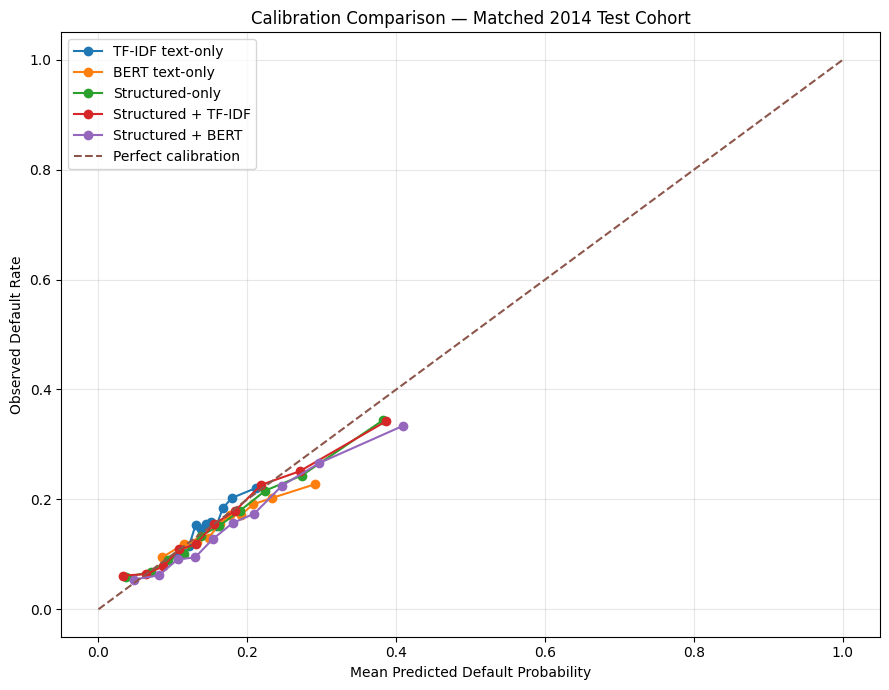

In [86]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

probability_models = {
    "TF-IDF text-only": tfidf_test_prob,
    "BERT text-only": bert_test_prob,
    "Structured-only": matched_struct_test_prob,
    "Structured + TF-IDF": hybrid_test_prob,
    "Structured + BERT": struct_bert_test_prob
}

plt.figure(figsize=(9, 7))

for name, probs in probability_models.items():

    observed_rate, mean_predicted = calibration_curve(
        y_text_test,
        probs,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        mean_predicted,
        observed_rate,
        marker="o",
        label=name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean Predicted Default Probability")
plt.ylabel("Observed Default Rate")
plt.title(
    "Calibration Comparison — Matched 2014 Test Cohort"
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [87]:
matched_calibration_results.to_csv(
    NB5_OUTPUT_DIR
    / "matched_representation_calibration.csv",
    index=False
)

print("Matched calibration results saved.")

Matched calibration results saved.


## 9. Summary of Text-Representation Experiments

This notebook evaluated whether borrower-written loan descriptions provide
incremental information for credit-risk prediction and compared sparse TF-IDF
and contextual BERT representations under a common temporal evaluation design.

On the held-out 2014 cohort, text-only models showed substantially weaker
discrimination than the matched structured-data baseline. BERT improved
ROC-AUC over TF-IDF in the text-only setting, indicating that contextual
representations captured additional information from borrower narratives.

When text was combined with structured predictors, both hybrid representations
produced modest improvements in ROC-AUC over the structured-only baseline.
Structured + BERT achieved the highest ROC-AUC, while Structured + TF-IDF
achieved the highest PR-AUC and lowest Brier score among the hybrid models.

Paired bootstrap analysis showed that the ROC-AUC improvements of both hybrid
models over the structured-only baseline were stable under resampling.
However, the difference between the BERT and TF-IDF hybrid models was not
clearly distinguishable in ROC-AUC or PR-AUC.

Calibration results further showed that increased representation complexity
did not consistently improve probability quality. Structured + TF-IDF produced
a lower Brier score and ECE than Structured + BERT on the matched test cohort.

Overall, borrower narratives provide modest incremental predictive information
beyond structured credit variables, but contextual BERT representations do not
uniformly outperform the simpler TF-IDF representation across discrimination
and probability-based evaluation criteria.

In [88]:
# Final representation comparison
final_representation_comparison.to_csv(
    NB5_OUTPUT_DIR / "final_representation_comparison.csv",
    index=False
)

# Calibration comparison
matched_calibration_results.to_csv(
    NB5_OUTPUT_DIR / "matched_representation_calibration.csv",
    index=False
)

# Paired bootstrap results
bootstrap_results.to_csv(
    NB5_OUTPUT_DIR / "representation_paired_bootstrap_comparison.csv",
    index=False
)

print("Notebook 05 final research artifacts saved.")

for path in [
    NB5_OUTPUT_DIR / "final_representation_comparison.csv",
    NB5_OUTPUT_DIR / "matched_representation_calibration.csv",
    NB5_OUTPUT_DIR / "representation_paired_bootstrap_comparison.csv"
]:
    print(path.name, "->", "FOUND" if path.exists() else "MISSING")

Notebook 05 final research artifacts saved.
final_representation_comparison.csv -> FOUND
matched_representation_calibration.csv -> FOUND
representation_paired_bootstrap_comparison.csv -> FOUND


In [98]:
import joblib
import numpy as np

# Persist the final Structured + TF-IDF research model
joblib.dump(
    hybrid_lr,
    NB5_OUTPUT_DIR / "structured_tfidf_logistic_model.joblib"
)

# Persist the fitted TF-IDF vectorizer
joblib.dump(
    tfidf_vectorizer,
    NB5_OUTPUT_DIR / "tfidf_vectorizer.joblib"
)

# Persist structured preprocessing objects
joblib.dump(
    matched_encoder,
    NB5_OUTPUT_DIR / "matched_categorical_encoder.joblib"
)

joblib.dump(
    matched_numeric_scaler,
    NB5_OUTPUT_DIR / "matched_numeric_scaler.joblib"
)

# Persist final test probabilities used in Notebook 06
np.save(
    NB5_OUTPUT_DIR / "structured_tfidf_test_prob.npy",
    hybrid_test_prob
)

np.save(
    NB5_OUTPUT_DIR / "structured_tfidf_val_prob.npy",
    hybrid_val_prob
)

print(
    "Validation probabilities saved:",
    hybrid_val_prob.shape
)

# Persist held-out test target for Notebook 06
np.save(
    NB5_OUTPUT_DIR / "y_text_test.npy",
    y_text_test
)

print(
    "Test target saved:",
    y_text_test.shape
)
print("Final Structured + TF-IDF artifacts saved.")

Validation probabilities saved: (48726,)
Test target saved: (15175,)
Final Structured + TF-IDF artifacts saved.


In [91]:
required_model_artifacts = [
    "structured_tfidf_logistic_model.joblib",
    "tfidf_vectorizer.joblib",
    "matched_categorical_encoder.joblib",
    "matched_numeric_scaler.joblib",
    "structured_tfidf_test_prob.npy"
]

for filename in required_model_artifacts:
    path = NB5_OUTPUT_DIR / filename

    print(
        filename,
        "->",
        "FOUND" if path.exists() else "MISSING"
    )

structured_tfidf_logistic_model.joblib -> FOUND
tfidf_vectorizer.joblib -> FOUND
matched_categorical_encoder.joblib -> FOUND
matched_numeric_scaler.joblib -> FOUND
structured_tfidf_test_prob.npy -> FOUND
